# Word2Vec

In [11]:
# Если Вы запускаете ноутбук на colab или kaggle,
# выполните следующие строчки, чтобы подгрузить библиотеку dlnlputils:

!git clone https://github.com/Samsung-IT-Academy/stepik-dl-nlp.git && pip install -r stepik-dl-nlp/requirements.txt
import sys; sys.path.append('./stepik-dl-nlp')

fatal: destination path 'stepik-dl-nlp' already exists and is not an empty directory.


In [12]:
# %load_ext autoreload
# %autoreload 2

import random
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import torch
from torch import nn
from torch.nn import functional as F

import dlnlputils
from dlnlputils.data import tokenize_corpus, build_vocabulary, texts_to_token_ids, \
    PaddedSequenceDataset, Embeddings
from dlnlputils.pipeline import train_eval_loop, predict_with_model, init_random_seed
from dlnlputils.visualization import plot_vectors

init_random_seed()

## Загрузка данных и подготовка корпуса

In [15]:
# Если Вы запускаете ноутбук на colab или kaggle, добавьте в начало пути ./stepik-dl-nlp
full_dataset = list(pd.read_csv('./stepik-dl-nlp/datasets/nyt-ingredients-snapshot-2015.csv')['input'].dropna())
random.shuffle(full_dataset)

TRAIN_VAL_SPLIT = int(len(full_dataset) * 0.7)
train_source = full_dataset[:TRAIN_VAL_SPLIT]
test_source = full_dataset[TRAIN_VAL_SPLIT:]
print("Обучающая выборка", len(train_source))
print("Тестовая выборка", len(test_source))
print()
print('\n'.join(train_source[:10]))

Обучающая выборка 125344
Тестовая выборка 53719

1/4 cup sour cream
10 ounces swordfish, red snapper or other firm-fleshed fish
1 tablespoon minced basil leaves
Handful fresh parsley, finely minced
4 ounces lard or butter, plus more for brushing tops
4 to 5 green cardamom pods
1 stick ( 1/4 pound) unsalted butter, softened
1/4 teaspoon red pepper flakes, preferably Turkish or Aleppo (see note), more to taste
1 tablespoon fresh lemon juice
1/4 cup scallions, thinly sliced


In [16]:
# токенизируем
train_tokenized = tokenize_corpus(train_source)
test_tokenized = tokenize_corpus(test_source)
print('\n'.join(' '.join(sent) for sent in train_tokenized[:10]))

sour cream
ounces swordfish snapper other firm fleshed fish
tablespoon minced basil leaves
handful fresh parsley finely minced
ounces lard butter plus more brushing tops
green cardamom pods
stick pound unsalted butter softened
teaspoon pepper flakes preferably turkish aleppo note more taste
tablespoon fresh lemon juice
scallions thinly sliced


In [17]:
# строим словарь
vocabulary, word_doc_freq = build_vocabulary(train_tokenized, max_doc_freq=0.9, min_count=5, pad_word='<PAD>')
print("Размер словаря", len(vocabulary))
print(list(vocabulary.items())[:10])

Размер словаря 2267
[('<PAD>', 0), ('tablespoons', 1), ('teaspoon', 2), ('chopped', 3), ('salt', 4), ('pepper', 5), ('cups', 6), ('ground', 7), ('fresh', 8), ('tablespoon', 9)]


In [20]:
# отображаем в номера токенов
train_token_ids = texts_to_token_ids(train_tokenized, vocabulary)
test_token_ids = texts_to_token_ids(test_tokenized, vocabulary)

print('\n'.join(' '.join(str(t) for t in sent)
                for sent in train_token_ids[:10]))

222 52
22 878 574 127 246 707 181
9 19 88 33
517 8 43 15 19
22 586 20 45 47 649 648
59 329 535
200 12 50 20 266
2 5 140 78 1208 735 153 47 10
9 8 31 25
98 65 27


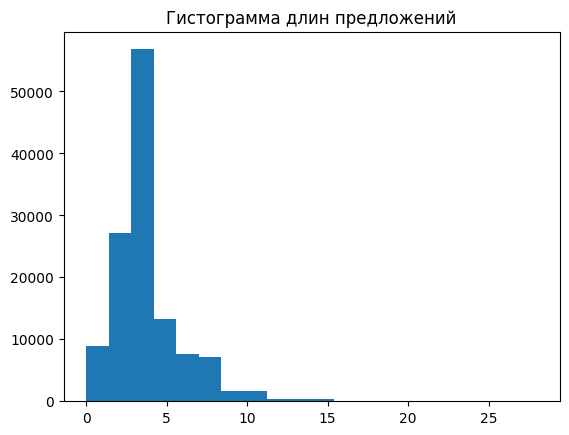

In [21]:
plt.hist([len(s) for s in train_token_ids], bins=20);
plt.title('Гистограмма длин предложений');

In [22]:
MAX_SENTENCE_LEN = 20
train_dataset = PaddedSequenceDataset(train_token_ids,
                                      np.zeros(len(train_token_ids)),
                                      out_len=MAX_SENTENCE_LEN)
test_dataset = PaddedSequenceDataset(test_token_ids,
                                     np.zeros(len(test_token_ids)),
                                     out_len=MAX_SENTENCE_LEN)
print(train_dataset[0])

(tensor([222,  52,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0]), tensor(0))


## Алгоритм обучения - Skip Gram Negative Sampling

**Skip Gram** - предсказываем соседние слова по центральному слову

**Negative Sampling** - аппроксимация softmax

$$ W, D \in \mathbb{R}^{Vocab \times EmbSize} $$

$$ \sum_{CenterW_i} P(CtxW_{-2}, CtxW_{-1}, CtxW_{+1}, CtxW_{+2} | CenterW_i; W, D) \rightarrow \max_{W,D} $$

$$ P(CtxW_{-2}, CtxW_{-1}, CtxW_{+1}, CtxW_{+2} | CenterW_i; W, D) = \prod_j P(CtxW_j | CenterW_i; W, D) $$
    
$$ P(CtxW_j | CenterW_i; W, D) = \frac{e^{w_i \cdot d_j}} { \sum_{j=1}^{|V|} e^{w_i \cdot d_j}} = softmax \simeq \frac{e^{w_i \cdot d_j^+}} { \sum_{j=1}^{k} e^{w_i \cdot d_j^-}}, \quad k \ll |V| $$

In [24]:
def make_diag_mask(size, radius):
    """Квадратная матрица размера Size x Size с двумя полосами ширины radius вдоль главной диагонали"""
    idxs = torch.arange(size)
    abs_idx_diff = (idxs.unsqueeze(0) - idxs.unsqueeze(1)).abs()
    mask = ((abs_idx_diff <= radius) & (abs_idx_diff > 0)).float()
    return mask

make_diag_mask(10, 3)

tensor([[0., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 1., 1., 1., 0., 0., 0.],
        [0., 1., 1., 1., 0., 1., 1., 1., 0., 0.],
        [0., 0., 1., 1., 1., 0., 1., 1., 1., 0.],
        [0., 0., 0., 1., 1., 1., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1., 1., 1., 0., 1.],
        [0., 0., 0., 0., 0., 0., 1., 1., 1., 0.]])

**Negative Sampling** работает следующим образом - мы **максимизируем сумму вероятностей двух событий**:

* "этот пример центрального слова вместе с контекстными словами взят **из тренировочной выборки**": $$ P(y=1 | CenterW_i; CtxW_j) = sigmoid(w_i \cdot d_j) = \frac{1}{1+e^{-w_i \cdot d_j}} $$

$$ \\ $$

* "этот пример центрального слова вместе со случайми контекстными словами **выдуман** ": $$ P(y=0 | CenterW_i; CtxW_{noise}) = 1 - P(y=1 | CenterW_i;  CtxW_{noise}) = \frac{1}{1+e^{w_i \cdot d_{noise}}} $$

$$ \\ $$

$$ NEG(CtxW_j, CenterW_i) = log(\frac{1}{1+e^{-w_i \cdot d_j}}) + \sum_{l=1}^{k}log(\frac{1}{1+e^{w_i \cdot d_{noise_l}}})  \rightarrow \max_{W,D} $$

In [25]:
class SkipGramNegativeSamplingTrainer(nn.Module):
    def __init__(self, vocab_size, emb_size, sentence_len, radius=5, negative_samples_n=5):
        super().__init__()
        self.vocab_size = vocab_size
        self.negative_samples_n = negative_samples_n

        self.center_emb = nn.Embedding(self.vocab_size, emb_size, padding_idx=0)
        self.center_emb.weight.data.uniform_(-1.0 / emb_size, 1.0 / emb_size)
        self.center_emb.weight.data[0] = 0

        self.context_emb = nn.Embedding(self.vocab_size, emb_size, padding_idx=0)
        self.context_emb.weight.data.uniform_(-1.0 / emb_size, 1.0 / emb_size)
        self.context_emb.weight.data[0] = 0

        self.positive_sim_mask = make_diag_mask(sentence_len, radius)

    def forward(self, sentences):
        """sentences - Batch x MaxSentLength - идентификаторы токенов"""
        batch_size = sentences.shape[0]
        center_embeddings = self.center_emb(sentences)  # Batch x MaxSentLength x EmbSize

        # оценить сходство с настоящими соседними словами
        positive_context_embs = self.context_emb(sentences).permute(0, 2, 1)  # Batch x EmbSize x MaxSentLength
        positive_sims = torch.bmm(center_embeddings, positive_context_embs)  # Batch x MaxSentLength x MaxSentLength
        positive_probs = torch.sigmoid(positive_sims)

        # увеличить оценку вероятности встретить эти пары слов вместе
        positive_mask = self.positive_sim_mask.to(positive_sims.device)
        positive_loss = F.binary_cross_entropy(positive_probs * positive_mask,
                                               positive_mask.expand_as(positive_probs))

        # выбрать случайные "отрицательные" слова
        negative_words = torch.randint(1, self.vocab_size,
                                       size=(batch_size, self.negative_samples_n),
                                       device=sentences.device)  # Batch x NegSamplesN
        negative_context_embs = self.context_emb(negative_words).permute(0, 2, 1)  # Batch x EmbSize x NegSamplesN
        negative_sims = torch.bmm(center_embeddings, negative_context_embs)  # Batch x MaxSentLength x NegSamplesN

        # уменьшить оценку вероятность встретить эти пары слов вместе
        negative_loss = F.binary_cross_entropy_with_logits(negative_sims,
                                                           negative_sims.new_zeros(negative_sims.shape))

        return positive_loss + negative_loss


def no_loss(pred, target):
    """Фиктивная функция потерь - когда модель сама считает функцию потерь"""
    return pred

## Обучение

In [26]:
trainer = SkipGramNegativeSamplingTrainer(len(vocabulary), 100, MAX_SENTENCE_LEN,
                                          radius=5, negative_samples_n=25)

In [27]:
best_val_loss, best_model = train_eval_loop(trainer,
                                            train_dataset,
                                            test_dataset,
                                            no_loss,
                                            lr=1e-2,
                                            epoch_n=2,
                                            batch_size=8,
                                            device='cpu',
                                            early_stopping_patience=10,
                                            max_batches_per_epoch_train=2000,
                                            max_batches_per_epoch_val=len(test_dataset),
                                            lr_scheduler_ctor=lambda optim: torch.optim.lr_scheduler.ReduceLROnPlateau(optim, patience=1))

Эпоха 0


/content/stepik-dl-nlp/dlnlputils/pipeline.py:120: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  mean_train_loss += float(loss)


Эпоха: 2001 итераций, 17.23 сек
Среднее значение функции потерь на обучении 0.8891311735287123
Среднее значение функции потерь на валидации 0.8816410118754195
Новая лучшая модель!

Эпоха 1
Эпоха: 2001 итераций, 15.33 сек
Среднее значение функции потерь на обучении 0.8791523958551234
Среднее значение функции потерь на валидации 0.878124304458621
Новая лучшая модель!



In [28]:
# Если Вы запускаете ноутбук на colab или kaggle, добавьте в начало пути ./stepik-dl-nlp
torch.save(trainer.state_dict(), './stepik-dl-nlp/models/sgns.pth')

In [29]:
# Если Вы запускаете ноутбук на colab или kaggle, добавьте в начало пути ./stepik-dl-nlp
trainer.load_state_dict(torch.load('./stepik-dl-nlp/models/sgns.pth'))

<All keys matched successfully>

## Исследуем характеристики полученных векторов

In [30]:
embeddings = Embeddings(trainer.center_emb.weight.detach().cpu().numpy(), vocabulary)

In [31]:
embeddings.most_similar('chicken')

[('chicken', np.float32(0.99994135)),
 ('breast', np.float32(0.6208601)),
 ('beef', np.float32(0.61580527)),
 ('giblets', np.float32(0.5981221)),
 ('breasts', np.float32(0.59007454)),
 ('broth', np.float32(0.5863513)),
 ('turkey', np.float32(0.5785218)),
 ('skinless', np.float32(0.5650985)),
 ('neck', np.float32(0.55654943)),
 ('stock', np.float32(0.5504561))]

In [32]:
embeddings.analogy('cake', 'cacao', 'cheese')

[('cheese', np.float32(0.99876344)),
 ('queso', np.float32(0.9524222)),
 ('fresco', np.float32(0.9146674)),
 ('fontina', np.float32(0.870536)),
 ('muenster', np.float32(0.8528007)),
 ('crumbled', np.float32(0.8369577)),
 ('cheeses', np.float32(0.8214982)),
 ('roquefort', np.float32(0.81836843)),
 ('goat', np.float32(0.8149054)),
 ('trahana', np.float32(0.80605155))]

In [33]:
test_words = ['salad', 'fish', 'salmon', 'sauvignon', 'beef', 'pork', 'steak', 'beer', 'cake', 'coffee', 'sausage', 'wine', 'merlot', 'zinfandel', 'trout', 'chardonnay', 'champagne', 'cacao']
test_vectors = embeddings.get_vectors(*test_words)
print(test_vectors.shape)

(18, 100)


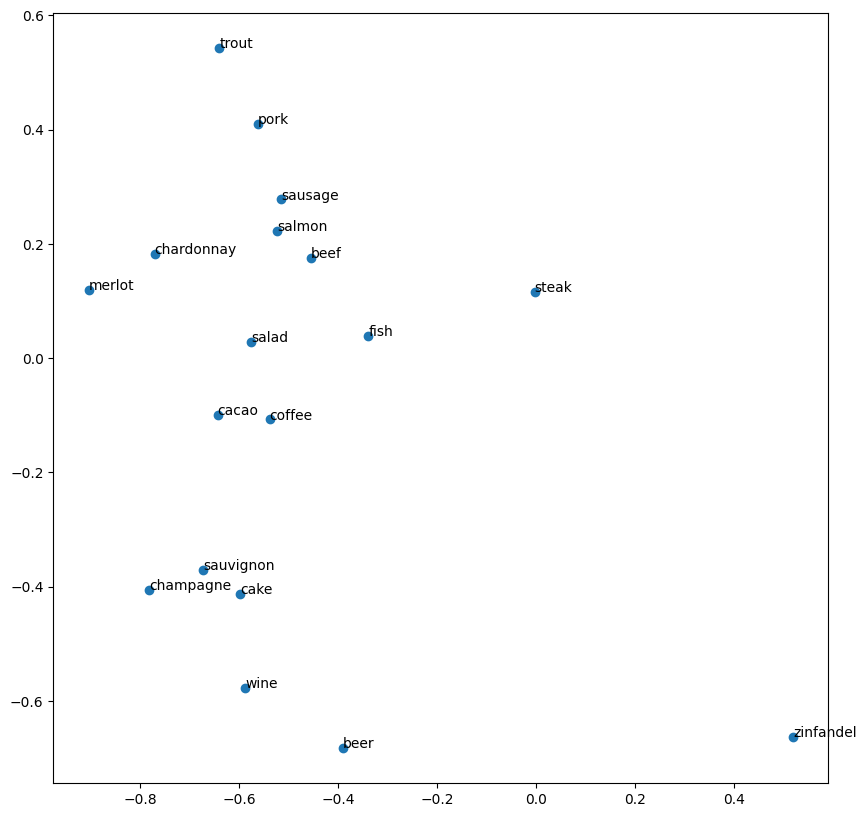

In [34]:
fig, ax = plt.subplots()
fig.set_size_inches((10, 10))
plot_vectors(test_vectors, test_words, how='svd', ax=ax)

## Обучение Word2Vec с помощью Gensim

In [23]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.2 MB/s eta 0:00:00
  Attempting uninstall: gensim
    Found existing installation: gensim 3.8.1
    Uninstalling gensim-3.8.1:
      Successfully uninstalled gensim-3.8.1


In [1]:
# import gensim

In [2]:
word2vec = gensim.models.Word2Vec(sentences=train_tokenized, size=100,
                                  window=5, min_count=5, workers=4,
                                  sg=1, iter=10)

In [ ]:
word2vec.wv.most_similar('chicken')

In [ ]:
gensim_words = [w for w in test_words if w in word2vec.wv.vocab]
gensim_vectors = np.stack([word2vec.wv[w] for w in gensim_words])

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches((10, 10))
plot_vectors(gensim_vectors, test_words, how='svd', ax=ax)

## Загрузка предобученного Word2Vec

Источники готовых векторов:

https://rusvectores.org/ru/ - для русского языка

https://wikipedia2vec.github.io/wikipedia2vec/pretrained/ - много разных языков

In [3]:
import gensim.downloader as api

In [4]:
available_models = api.info()['models'].keys()
print('\n'.join(available_models))

fasttext-wiki-news-subwords-300
conceptnet-numberbatch-17-06-300
word2vec-ruscorpora-300
word2vec-google-news-300
glove-wiki-gigaword-50
glove-wiki-gigaword-100
glove-wiki-gigaword-200
glove-wiki-gigaword-300
glove-twitter-25
glove-twitter-50
glove-twitter-100
glove-twitter-200
__testing_word2vec-matrix-synopsis


In [5]:
pretrained = api.load('word2vec-google-news-300')  # > 1.5 GB!

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [6]:
pretrained.most_similar('cheese')

[('cheeses', 0.7788999676704407),
 ('cheddar', 0.7627597451210022),
 ('goat_cheese', 0.7297402024269104),
 ('Cheese', 0.7286962270736694),
 ('cheddar_cheese', 0.725513756275177),
 ('Cheddar_cheese', 0.6943708658218384),
 ('mozzarella', 0.6805710792541504),
 ('cheddar_cheeses', 0.6694672107696533),
 ('Camembert', 0.6623162031173706),
 ('gruyere', 0.6615148186683655)]

In [7]:
pretrained.most_similar(positive=['man', 'queen'], negative=['king'])

[('woman', 0.7609436511993408),
 ('girl', 0.6139993667602539),
 ('teenage_girl', 0.6040961742401123),
 ('teenager', 0.5825759172439575),
 ('lady', 0.5752554535865784),
 ('boy', 0.5077577233314514),
 ('policewoman', 0.5066847801208496),
 ('schoolgirl', 0.5052095651626587),
 ('blonde', 0.48696184158325195),
 ('person', 0.48637545108795166)]

In [9]:
pretrained_words = [w for w in test_words if w in pretrained.vocab]
pretrained_vectors = np.stack([pretrained[w] for w in pretrained_words])

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches((10, 10))
plot_vectors(pretrained_vectors, test_words, how='svd', ax=ax)

## Заключение

* Реализовали Skip Gram Negative Sampling на PyTorch
* Обучили на корпусе рецептов
    * Сходство слов модель выучила неплохо
    * Для аналогий мало данных
* Обучили SGNS с помощью библиотеки Gensim
* Загрузили веса Word2Vec, полученные с помощью большого корпуса (GoogleNews)
    * Списки похожих слов отличаются!
    * Аналогии работают

Строим словарь n-грамм...
Размер словаря n-грамм: 25057
Строим карту слово - n-граммы...

Параметров в FastText:  2,732,500
Параметров в Word2Vec:  453,400

Обучаем FastText...
Эпоха 0
Эпоха: 2001 итераций, 70.81 сек
Среднее значение функции потерь на обучении 0.8863439735980226
Среднее значение функции потерь на валидации 0.8794195567327743
Новая лучшая модель!

Эпоха 1
Эпоха: 2001 итераций, 73.56 сек
Среднее значение функции потерь на обучении 0.8774313824525897
Среднее значение функции потерь на валидации 0.8756819184822372
Новая лучшая модель!


СРАВНЕНИЕ ПОХОЖИХ СЛОВ: Word2Vec vs FastText

[CHICKEN]
  Word2Vec : chicken (1.000), breast (0.621), beef (0.616), giblets (0.598), breasts (0.590)
  FastText : chickens (0.954), chick (0.819), breasts (0.751), turkey (0.736), thighs (0.705)

[WINE]
  Word2Vec : wine (1.000), blanc (0.723), bottle (0.709), champagne (0.689), sauvignon (0.680)
  FastText : twine (0.853), sherry (0.771), vinegar (0.754), champagne (0.749), bottle (0.745)

[C

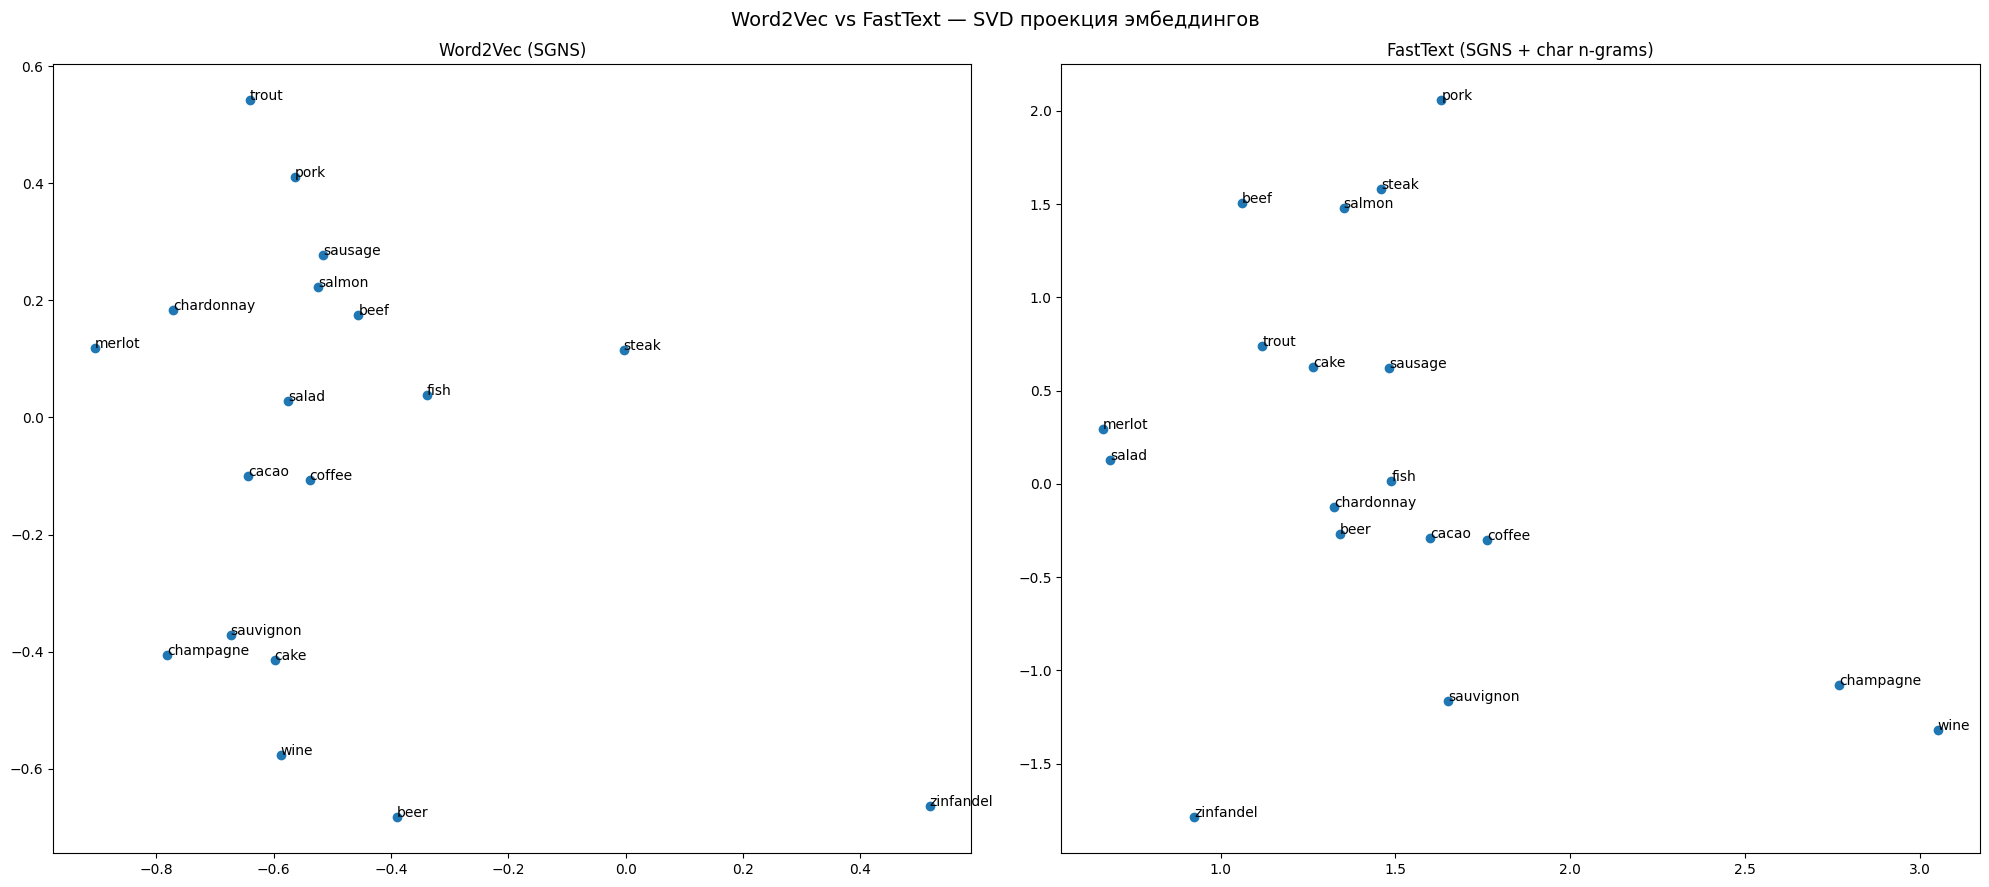


Готово! FastText обучен и сравнён с Word2Vec.


In [36]:
import torch
from torch import nn
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt
from dlnlputils.visualization import plot_vectors

def get_char_ngrams(word: str, min_n: int = 3, max_n: int = 6) -> list[str]:
    word_marked = f"<{word}>"
    ngrams = []
    for n in range(min_n, max_n + 1):
        for i in range(len(word_marked) - n + 1):
            ngrams.append(word_marked[i:i + n])

    ngrams.append(word_marked)
    return ngrams


def build_ngram_vocabulary(word_vocab: dict,
                           min_n: int = 3,
                           max_n: int = 6) -> dict[str, int]:
    ngram_set = set()
    for word in word_vocab:
        if word == '<PAD>':
            continue
        for ng in get_char_ngrams(word, min_n, max_n):
            ngram_set.add(ng)

    ngram_vocab = {ng: idx + 1 for idx, ng in enumerate(sorted(ngram_set))}
    print(f"Размер словаря n-грамм: {len(ngram_vocab)}")
    return ngram_vocab


def word_to_ngram_ids(word: str,
                      ngram_vocab: dict[str, int],
                      min_n: int = 3,
                      max_n: int = 6) -> list[int]:
    return [ngram_vocab[ng]
            for ng in get_char_ngrams(word, min_n, max_n)
            if ng in ngram_vocab]


def build_word_to_ngram_ids_map(word_vocab: dict,
                                ngram_vocab: dict[str, int],
                                max_ngrams_per_word: int = 20,
                                min_n: int = 3,
                                max_n: int = 6) -> torch.Tensor:

    vocab_size = len(word_vocab)
    mapping = torch.zeros(vocab_size, max_ngrams_per_word, dtype=torch.long)

    id_to_word = {v: k for k, v in word_vocab.items()}

    for word_id in range(1, vocab_size):
        word = id_to_word.get(word_id, '')
        if not word or word == '<PAD>':
            continue
        ng_ids = word_to_ngram_ids(word, ngram_vocab, min_n, max_n)
        ng_ids = ng_ids[:max_ngrams_per_word]
        mapping[word_id, :len(ng_ids)] = torch.tensor(ng_ids)

    return mapping


class FastTextNegativeSamplingTrainer(nn.Module):
    def __init__(self,
                 vocab_size: int,
                 ngram_vocab_size: int,
                 word_to_ngram_ids: torch.Tensor,
                 emb_size: int = 100,
                 sentence_len: int = 20,
                 radius: int = 5,
                 negative_samples_n: int = 25):
        super().__init__()
        self.vocab_size = vocab_size
        self.negative_samples_n = negative_samples_n

        self.ngram_emb = nn.Embedding(ngram_vocab_size + 1, emb_size, padding_idx=0)
        self.ngram_emb.weight.data.uniform_(-1.0 / emb_size, 1.0 / emb_size)
        self.ngram_emb.weight.data[0] = 0

        self.context_emb = nn.Embedding(vocab_size, emb_size, padding_idx=0)
        self.context_emb.weight.data.uniform_(-1.0 / emb_size, 1.0 / emb_size)
        self.context_emb.weight.data[0] = 0

        self.register_buffer('word_to_ngram_ids', word_to_ngram_ids)

        self.positive_sim_mask = self._make_diag_mask(sentence_len, radius)

    @staticmethod
    def _make_diag_mask(size: int, radius: int) -> torch.Tensor:
        idxs = torch.arange(size)
        diff = (idxs.unsqueeze(0) - idxs.unsqueeze(1)).abs()
        return ((diff <= radius) & (diff > 0)).float()

    def get_word_embeddings(self, word_ids: torch.Tensor) -> torch.Tensor:
        ngram_ids = self.word_to_ngram_ids[word_ids]
        ngram_vecs = self.ngram_emb(ngram_ids)
        mask = (ngram_ids > 0).float().unsqueeze(-1)
        ngram_count = mask.sum(dim=2).clamp(min=1)
        word_vecs = (ngram_vecs * mask).sum(dim=2) / ngram_count
        return word_vecs

    def forward(self, sentences: torch.Tensor) -> torch.Tensor:
        batch_size = sentences.shape[0]

        center_embeddings = self.get_word_embeddings(sentences)

        ctx_embs = self.context_emb(sentences).permute(0, 2, 1)
        pos_sims = torch.bmm(center_embeddings, ctx_embs)
        pos_probs = torch.sigmoid(pos_sims)
        pos_mask = self.positive_sim_mask.to(pos_sims.device)
        positive_loss = F.binary_cross_entropy(
            pos_probs * pos_mask,
            pos_mask.expand_as(pos_probs)
        )

        neg_words = torch.randint(1, self.vocab_size,
                                  size=(batch_size, self.negative_samples_n),
                                  device=sentences.device)
        neg_ctx = self.context_emb(neg_words).permute(0, 2, 1)
        neg_sims = torch.bmm(center_embeddings, neg_ctx)
        negative_loss = F.binary_cross_entropy_with_logits(
            neg_sims,
            neg_sims.new_zeros(neg_sims.shape)
        )

        return positive_loss + negative_loss

class FastTextEmbeddings:
    def __init__(self,
                 model: FastTextNegativeSamplingTrainer,
                 vocabulary: dict[str, int],
                 ngram_vocab: dict[str, int],
                 min_n: int = 3,
                 max_n: int = 6):
        self.model = model
        self.vocabulary = vocabulary
        self.ngram_vocab = ngram_vocab
        self.min_n = min_n
        self.max_n = max_n
        self.id_to_word = {v: k for k, v in vocabulary.items()}

        self._word_vectors = self._compute_all_vectors()

    def _compute_all_vectors(self) -> np.ndarray:
        self.model.eval()
        vocab_size = len(self.vocabulary)
        all_ids = torch.arange(vocab_size).unsqueeze(0)
        with torch.no_grad():
            vecs = self.model.get_word_embeddings(all_ids)
        return vecs.squeeze(0).numpy()

    def get_vector(self, word: str) -> np.ndarray:
        if word in self.vocabulary:
            return self._word_vectors[self.vocabulary[word]]

        ng_ids = word_to_ngram_ids(word, self.ngram_vocab, self.min_n, self.max_n)
        if not ng_ids:
            return np.zeros(self._word_vectors.shape[1])
        ids_tensor = torch.tensor(ng_ids)
        with torch.no_grad():
            vecs = self.model.ngram_emb(ids_tensor)  # [N, E]
        return vecs.mean(dim=0).numpy()

    def most_similar(self, word: str, topn: int = 10) -> list[tuple[str, float]]:
        vec = self.get_vector(word)
        vec_norm = vec / (np.linalg.norm(vec) + 1e-9)

        norms = np.linalg.norm(self._word_vectors, axis=1, keepdims=True) + 1e-9
        sims = self._word_vectors.dot(vec_norm) / norms.squeeze()

        exclude_ids = {0, self.vocabulary.get(word, -1)}
        top_ids = np.argsort(-sims)
        results = []
        for idx in top_ids:
            if idx in exclude_ids:
                continue
            results.append((self.id_to_word[idx], float(sims[idx])))
            if len(results) >= topn:
                break
        return results

    def get_vectors(self, *words: str) -> np.ndarray:
        return np.stack([self.get_vector(w) for w in words])


MIN_N, MAX_N = 3, 6
MAX_NGRAMS_PER_WORD = 20

print("Строим словарь n-грамм...")
ngram_vocab = build_ngram_vocabulary(vocabulary, MIN_N, MAX_N)

print("Строим карту слово - n-граммы...")
word_ngram_map = build_word_to_ngram_ids_map(
    vocabulary, ngram_vocab,
    max_ngrams_per_word=MAX_NGRAMS_PER_WORD,
    min_n=MIN_N, max_n=MAX_N
)

ft_trainer = FastTextNegativeSamplingTrainer(
    vocab_size=len(vocabulary),
    ngram_vocab_size=len(ngram_vocab),
    word_to_ngram_ids=word_ngram_map,
    emb_size=100,
    sentence_len=MAX_SENTENCE_LEN,
    radius=5,
    negative_samples_n=25
)

print(f"\nПараметров в FastText:  {sum(p.numel() for p in ft_trainer.parameters()):,}")
print(f"Параметров в Word2Vec:  {sum(p.numel() for p in trainer.parameters()):,}")

from dlnlputils.pipeline import train_eval_loop

def no_loss(pred, target):
    return pred

print("\nОбучаем FastText...")
best_val_loss_ft, best_ft_model = train_eval_loop(
    ft_trainer,
    train_dataset,
    test_dataset,
    no_loss,
    lr=1e-2,
    epoch_n=2,
    batch_size=8,
    device='cpu',
    early_stopping_patience=10,
    max_batches_per_epoch_train=2000,
    max_batches_per_epoch_val=len(test_dataset),
    lr_scheduler_ctor=lambda optim: torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim, patience=1
    )
)

ft_embeddings = FastTextEmbeddings(ft_trainer, vocabulary, ngram_vocab, MIN_N, MAX_N)


compare_words = ['chicken', 'wine', 'cake', 'salmon']

print("\n" + "="*60)
print("СРАВНЕНИЕ ПОХОЖИХ СЛОВ: Word2Vec vs FastText")
print("="*60)

from dlnlputils.data import Embeddings
w2v_embeddings = Embeddings(trainer.center_emb.weight.detach().cpu().numpy(), vocabulary)

for word in compare_words:
    print(f"\n[{word.upper()}]")
    w2v_sim  = w2v_embeddings.most_similar(word)
    ft_sim   = ft_embeddings.most_similar(word)

    w2v_words = [f"{w} ({s:.3f})" for w, s in w2v_sim[:5]]
    ft_words  = [f"{w} ({s:.3f})" for w, s in ft_sim[:5]]

    print(f"  Word2Vec : {', '.join(w2v_words)}")
    print(f"  FastText : {', '.join(ft_words)}")

print("\n" + "="*60)
print("OOV-СЛОВА (слова не из словаря)")
print("="*60)

oov_words = ['chickens', 'wines', 'baking', 'grilled', 'marinated']

for word in oov_words:
    in_vocab = word in vocabulary
    ft_vec   = ft_embeddings.get_vector(word)
    ft_sim   = ft_embeddings.most_similar(word, topn=3)
    top3     = ', '.join(f"{w} ({s:.3f})" for w, s in ft_sim)
    status   = "в словаре" if in_vocab else "OOV"
    print(f"  '{word}' [{status}] - FastText: {top3}")


test_words_available = [w for w in test_words if w in vocabulary]

w2v_vecs = np.array([w2v_embeddings.get_vector(w) for w in test_words_available])
ft_vecs = np.array([ft_embeddings.get_vector(w) for w in test_words_available])

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle("Word2Vec vs FastText — SVD проекция эмбеддингов", fontsize=14)

plot_vectors(w2v_vecs, test_words_available, how='svd', ax=axes[0])
axes[0].set_title("Word2Vec (SGNS)")

plot_vectors(ft_vecs, test_words_available, how='svd', ax=axes[1])
axes[1].set_title("FastText (SGNS + char n-grams)")

plt.tight_layout()
plt.show()

print("\nГотово! FastText обучен и сравнён с Word2Vec.")